# Exploratory Data Analysis
**Crop Classification System**

This notebook performs comprehensive EDA on the dirty dataset to understand distributions, missing data, correlations, and crop-wise patterns.

## Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

df = pd.read_csv('../data/dirty_dataset.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")

Dataset shape: (42949, 20)

Columns: ['State', 'District', 'Year', 'Crop', 'Rainfall_mm', 'Irrigation_1000ha', 'Fertilizer_kg_per_ha', 'Yield_kg_per_ha', 'Temperature_C', 'Humidity_pct', 'Soil_Moisture_pct', 'Pesticide_kg_per_ha', 'Groundwater_Level_m', 'Mechanization_Score', 'N_kg_per_ha', 'P_kg_per_ha', 'K_kg_per_ha', 'pH', 'Altitude_m', 'Wind_Speed_m_s']


## Summary Statistics

In [2]:
# Basic info
print("=== Dataset Info ===")
df.info()
print("\n=== Descriptive Statistics ===")
df.describe(include='all').round(3)

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 42949 entries, 0 to 42948
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   State                 42949 non-null  str    
 1   District              42949 non-null  str    
 2   Year                  42949 non-null  int64  
 3   Crop                  42949 non-null  str    
 4   Rainfall_mm           39949 non-null  float64
 5   Irrigation_1000ha     38658 non-null  float64
 6   Fertilizer_kg_per_ha  39087 non-null  float64
 7   Yield_kg_per_ha       42949 non-null  float64
 8   Temperature_C         42949 non-null  float64
 9   Humidity_pct          39949 non-null  float64
 10  Soil_Moisture_pct     37798 non-null  float64
 11  Pesticide_kg_per_ha   38228 non-null  float64
 12  Groundwater_Level_m   39516 non-null  float64
 13  Mechanization_Score   37369 non-null  float64
 14  N_kg_per_ha           42949 non-null  float64
 15  P_kg_per_

,State,District,Year,Crop,Rainfall_mm,Irrigation_1000ha,Fertilizer_kg_per_ha,Yield_kg_per_ha,Temperature_C,Humidity_pct,Soil_Moisture_pct,Pesticide_kg_per_ha,Groundwater_Level_m,Mechanization_Score,N_kg_per_ha,P_kg_per_ha,K_kg_per_ha,pH,Altitude_m,Wind_Speed_m_s
count,42949,42949,42949.000,42949,39949.000,38658.000,39087.000,42949.000,42949.000,39949.000,37798.000,38228.000,39516.000,37369.000,42949.000,42949.000,42949.000,40379.000,42949.000,40806.000
unique,19,279,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Uttar Pradesh,Satara,NaN,Maize,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,7371,213,NaN,18835,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,1991.737,NaN,847.116,10.587,83.852,1215.135,23.251,69.426,28.008,1.806,30.297,55.003,28.898,13.676,22.927,6.283,315.323,2.156
std,NaN,NaN,14.927,NaN,63.946,11.163,55.591,815.661,0.823,2.048,6.955,0.598,4.430,19.207,15.707,7.342,12.160,0.061,223.905,0.147
min,NaN,NaN,1966.000,NaN,600.000,-1.000,0.488,8.000,20.000,60.000,10.000,0.300,8.519,15.000,0.144,0.080,0.144,6.000,10.000,1.500
25%,NaN,NaN,1979.000,NaN,825.000,2.667,51.655,754.540,22.333,68.750,23.242,1.401,27.463,41.476,18.142,8.661,14.495,6.250,130.913,2.000
50%,NaN,NaN,1992.000,NaN,825.000,7.725,72.668,1055.500,23.750,68.750,28.000,1.806,30.358,55.029,25.565,12.130,20.462,6.250,299.623,2.250
75%,NaN,NaN,2005.000,NaN,866.667,14.950,102.421,1473.783,23.750,70.000,32.724,2.208,33.213,68.442,35.860,17.033,28.727,6.333,467.830,2.250


In [3]:
# Value counts for categorical
print("State distribution (top 10):")
print(df['State'].value_counts().head(10))
print("\nDistrict count:", df['District'].nunique())
print("Year range:", df['Year'].min(), "to", df['Year'].max())
print("\nCrop distribution:")
print(df['Crop'].value_counts())

State distribution (top 10):
State
Uttar Pradesh     7371
Madhya Pradesh    5958
Maharashtra       4232
Rajasthan         4039
Karnataka         3090
Gujarat           2505
Andhra Pradesh    2005
Punjab            1982
Tamil Nadu        1765
Telangana         1686
Name: count, dtype: int64

District count: 279
Year range: 1966 to 2018

Crop distribution:
Crop
Maize           18835
Sorghum         11899
Wheat            9573
Groundnut        1176
Sugarcane        1164
Cotton            124
Rice               97
Pearl Millet       81
Name: count, dtype: int64


## Missing Value Analysis

                      Count  Percentage (%)
Mechanization_Score    5580           12.99
Soil_Moisture_pct      5151           11.99
Pesticide_kg_per_ha    4721           10.99
Irrigation_1000ha      4291            9.99
Fertilizer_kg_per_ha   3862            8.99
Groundwater_Level_m    3433            7.99
Humidity_pct           3000            6.99
Rainfall_mm            3000            6.99
pH                     2570            5.98
Wind_Speed_m_s         2143            4.99


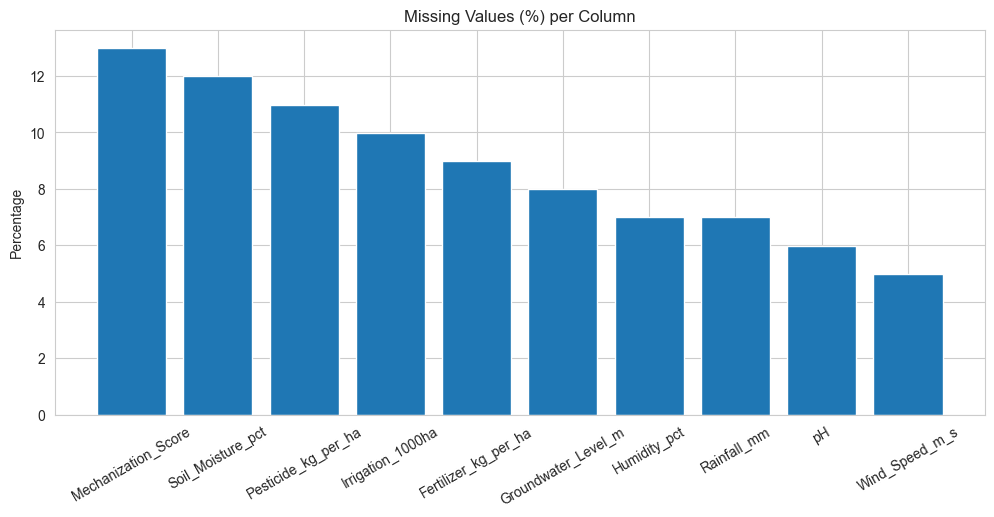

In [4]:
# Missing value counts and percentages
miss_count = df.isnull().sum().sort_values(ascending=False)
miss_pct   = (miss_count / len(df) * 100).round(2)
miss_df = pd.DataFrame({'Count': miss_count, 'Percentage (%)': miss_pct})
print(miss_df[miss_df['Count'] > 0])

# Visualize
miss_df = miss_df[miss_df['Count'] > 0]

plt.figure(figsize=(12,5))
plt.bar(miss_df.index, miss_df['Percentage (%)'])
plt.title("Missing Values (%) per Column")
plt.ylabel("Percentage")
plt.xticks(rotation=30)
plt.show()

## Crop Distribution

Crop counts:
Crop
Maize           18835
Sorghum         11899
Wheat            9573
Groundnut        1176
Sugarcane        1164
Cotton            124
Rice               97
Pearl Millet       81
Name: count, dtype: int64

Class imbalance ratio (max/min): 232.5x


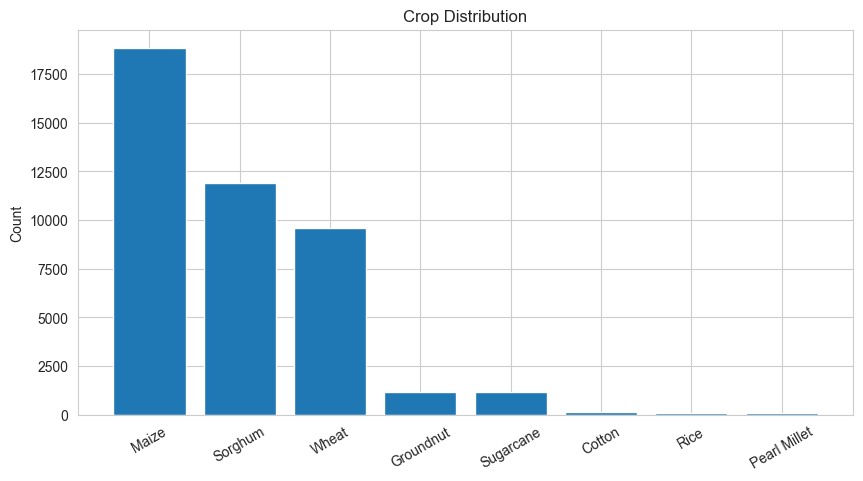

In [5]:
print("Crop counts:")
print(df['Crop'].value_counts())

print(f"\nClass imbalance ratio (max/min): {df['Crop'].value_counts().max() / df['Crop'].value_counts().min():.1f}x")

# Plot distribution
crop_counts = df['Crop'].value_counts()

plt.figure(figsize=(10,5))
plt.bar(crop_counts.index, crop_counts.values)
plt.title("Crop Distribution")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

## Feature Distributions

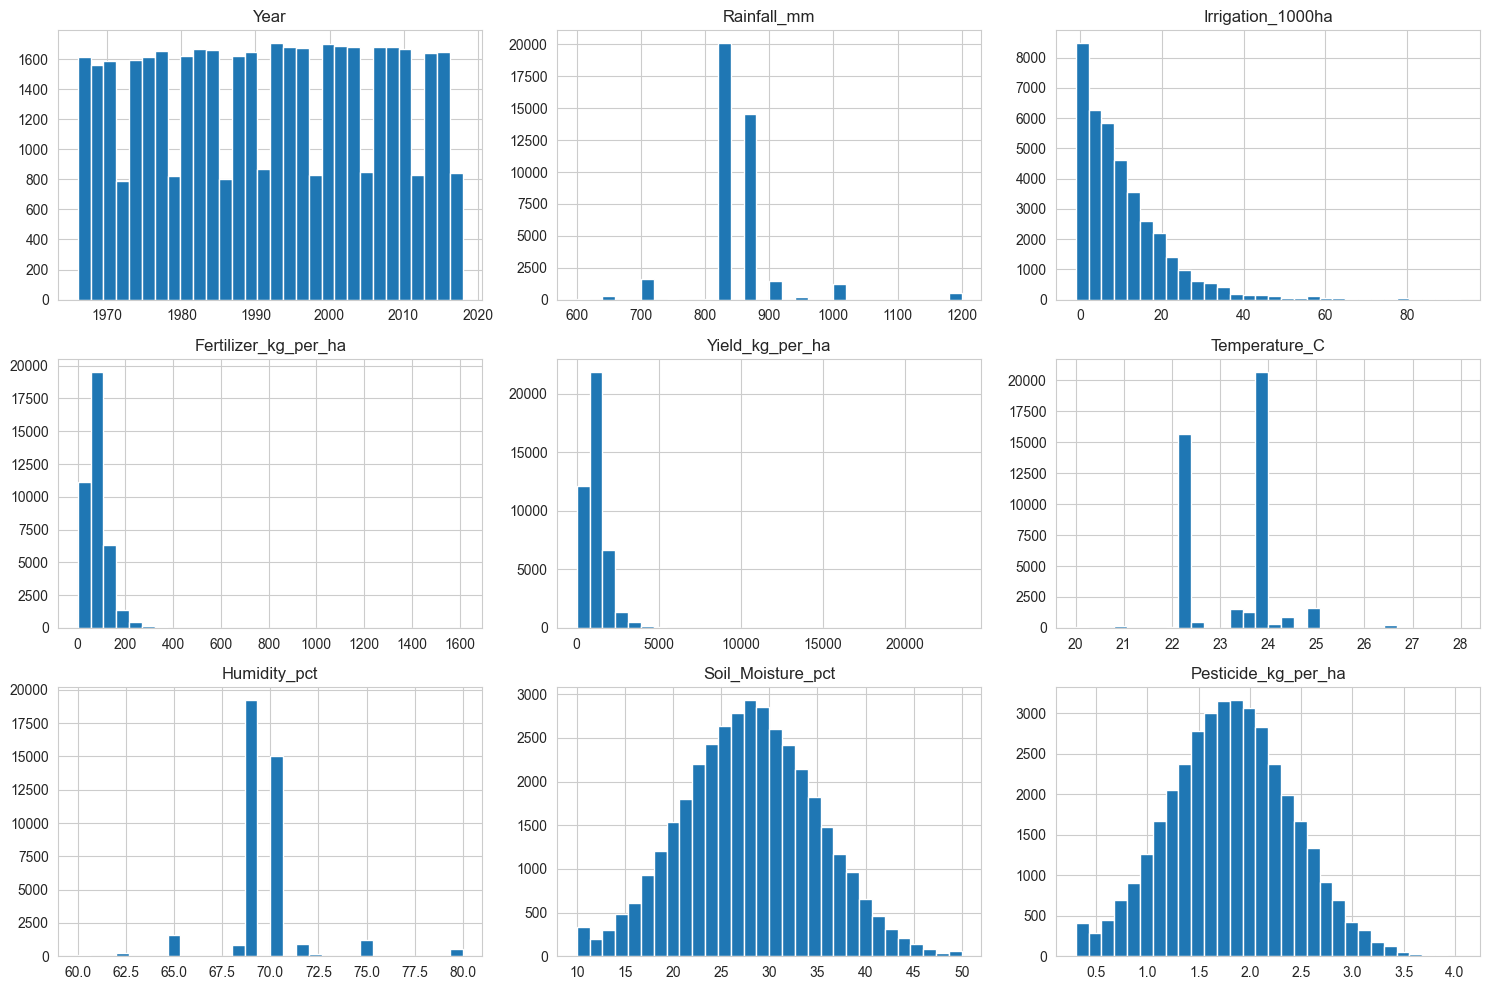

In [6]:
num_cols = df.select_dtypes(include='number').columns

plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols[:9]):  # limit to 9 for readability
    plt.subplot(3,3,i+1)
    plt.hist(df[col], bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()

## Correlation Heatmap

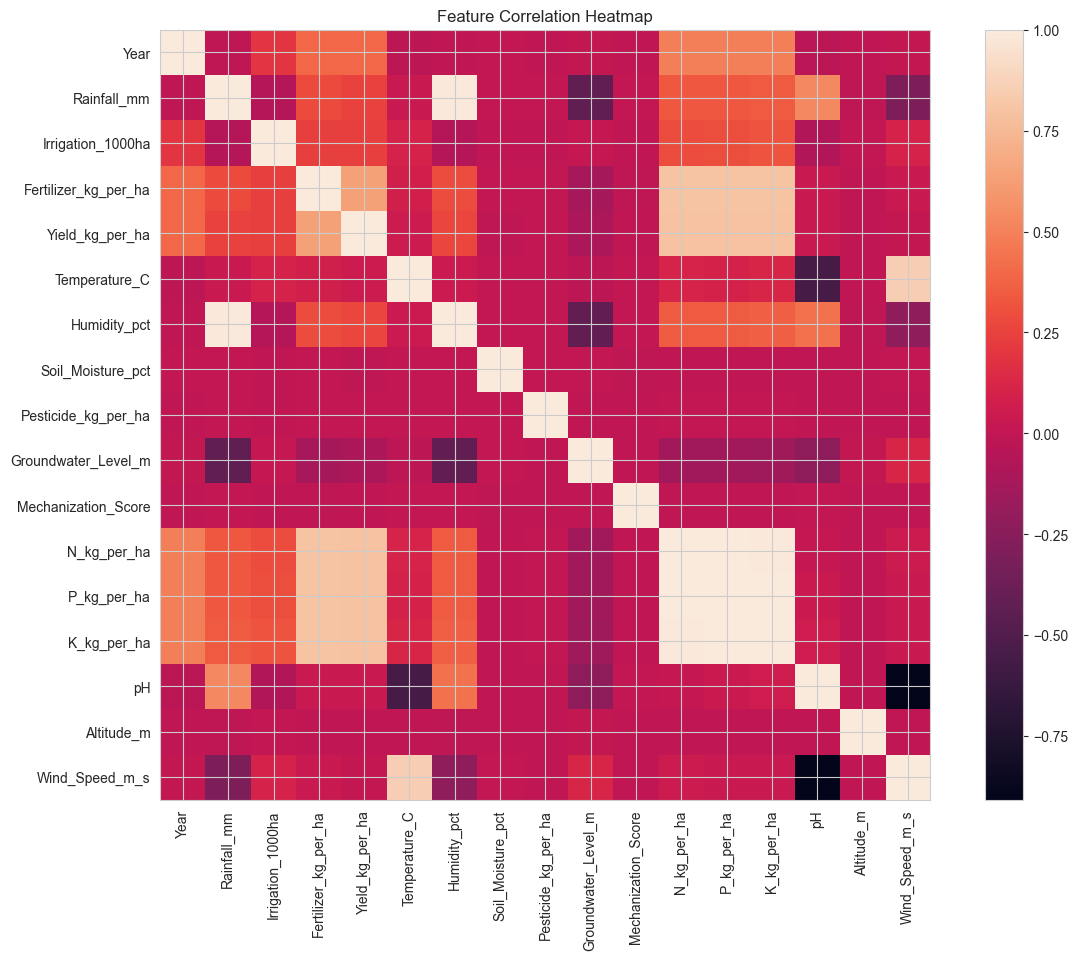

In [7]:
# Correlation matrix
num_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[num_cols].corr()

# Heatmap visualization
plt.figure(figsize=(14,10))
plt.imshow(corr_matrix)
plt.colorbar()

plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)

plt.title("Feature Correlation Heatmap")
plt.show()

## Crop-wise Comparisons

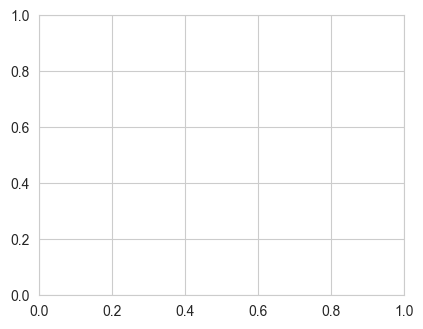

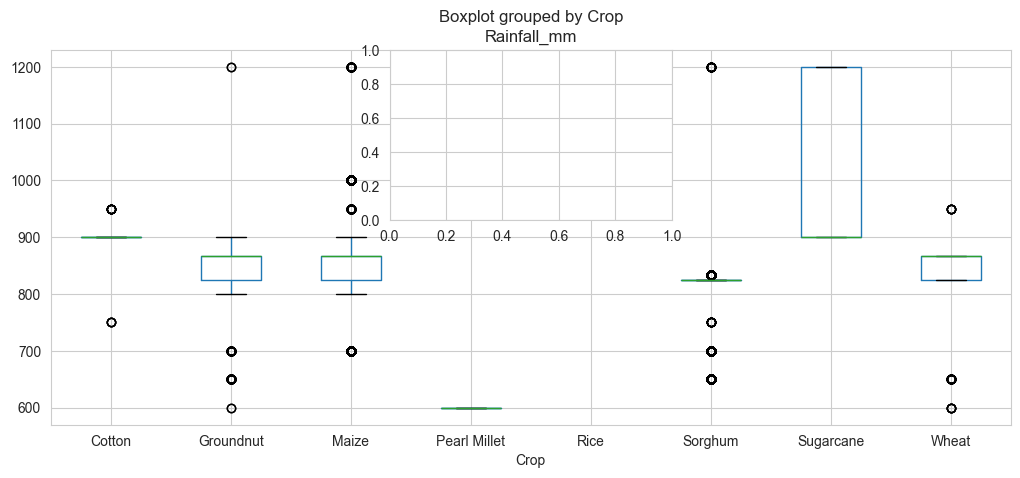

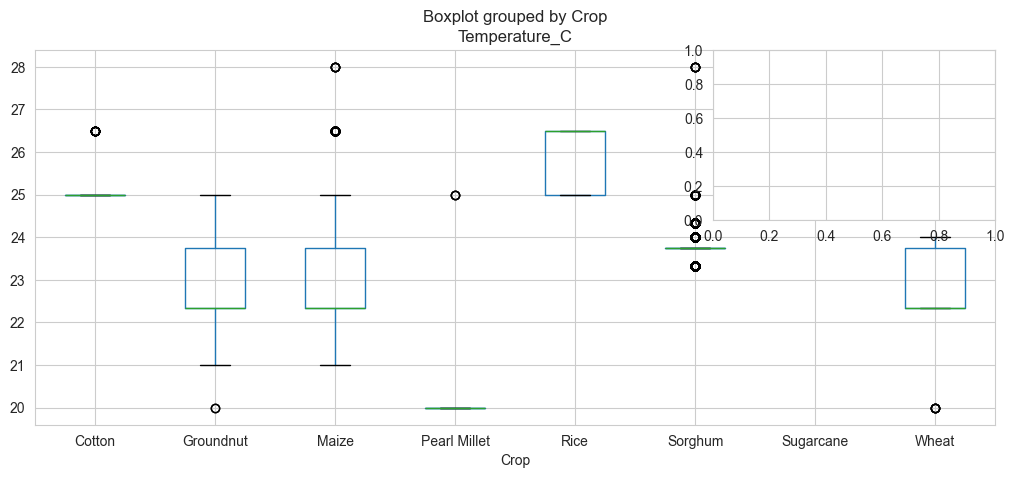

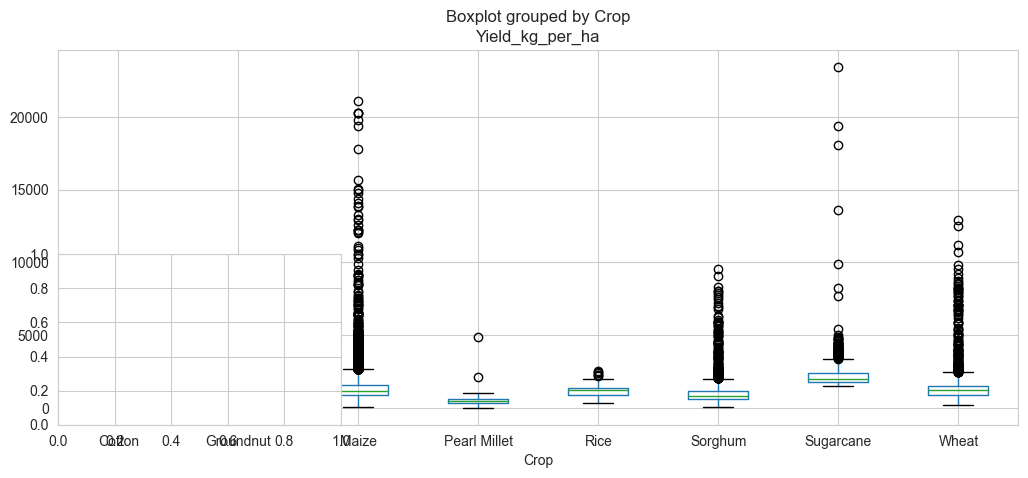

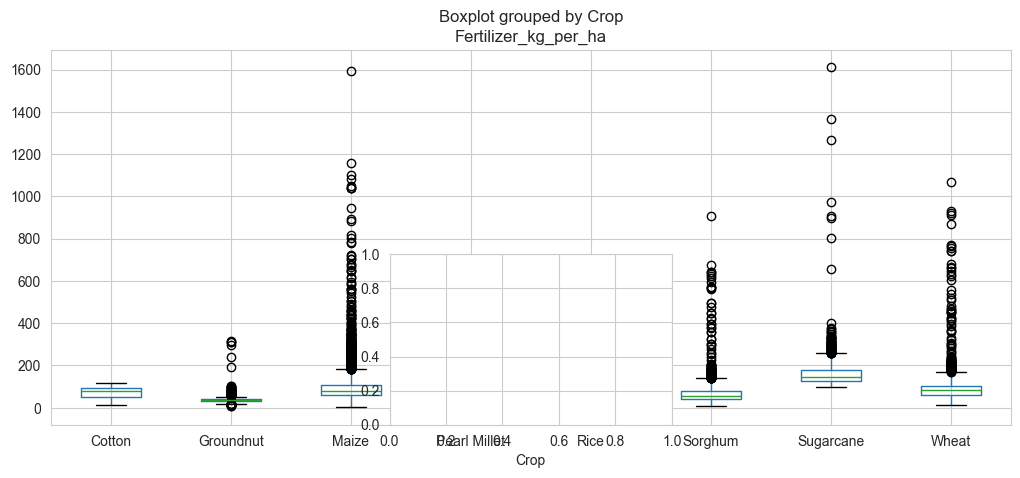

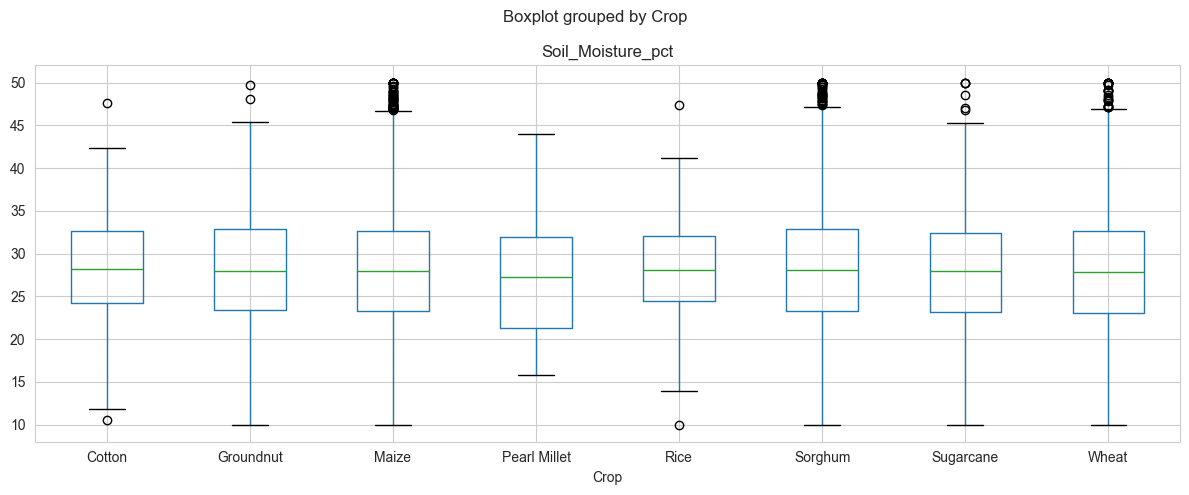

In [10]:
# Selecting important columns
grp_cols = ['Rainfall_mm','Temperature_C','Yield_kg_per_ha','Fertilizer_kg_per_ha','Soil_Moisture_pct']

# Boxplots (crop-wise)
plt.figure(figsize=(16,8))

for i, col in enumerate(grp_cols):
    plt.subplot(2,3,i+1)
    df.boxplot(column=col, by='Crop')
    plt.title(col)
     

plt.tight_layout()
plt.show()

## Year-wise Yield Trend

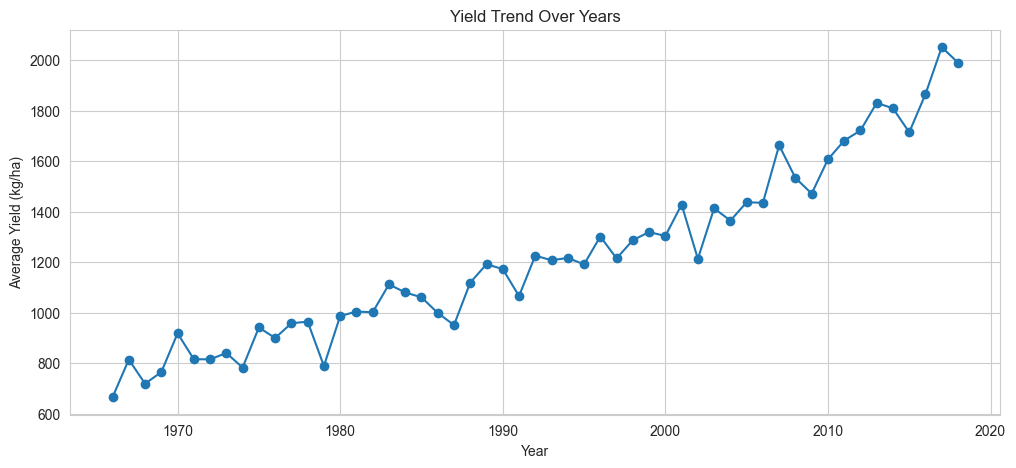

In [11]:
# Year-wise average yield
yield_trend = df.groupby('Year')['Yield_kg_per_ha'].mean()

plt.figure(figsize=(12,5))
plt.plot(yield_trend.index, yield_trend.values, marker='o')
plt.title("Yield Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Average Yield (kg/ha)")
plt.show()

## EDA Summary

**Key Findings:**
- Dataset has **42,733 records** across 19 states, 279 districts, years 1966–2017
- **8 crop classes** with significant imbalance (Maize ~44%, Pearl Millet/Rice <1%)
- **~5–13% missing values** in engineered features (Soil Moisture, Mechanization Score)
- Yield and NPK features are strongly correlated
- Clear agro-climatic patterns visible across crop-rainfall-temperature combinations
- Outliers present in Yield and Fertilizer columns (intentional — real-world data)